In [1]:
import torch

print("=== Environment ===")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠  No GPU detected — Runtime → Change runtime type → T4 GPU")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_ID = 0 if torch.cuda.is_available() else -1
print(f"\nUsing: {DEVICE}")


=== Environment ===
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB

Using: cuda


In [20]:
!pip install gliner
!pip install -q flair
!pip install -q scispacy
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bionlp13cg_md-0.5.4.tar.gz
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_jnlpba_md-0.5.4.tar.gz

ERROR: Operation cancelled by user
  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz (14.8 MB)
  Preparing metadata (setup.py) ... done


### Schema

In [4]:
from enum import Enum

class EntityType(str, Enum):
    # Coding / sequence elements
    GENE                            = "GENE"
    PROTEIN                         = "PROTEIN"
    TRANSCRIPT                      = "TRANSCRIPT"
    EXON                            = "EXON"
    NON_CODING_RNA                  = "NON_CODING_RNA"
    # Genomic variation
    GENOMIC_VARIANT                 = "GENOMIC_VARIANT"
    SEQUENCE_VARIANT                = "SEQUENCE_VARIANT"
    STRUCTURAL_VARIANT              = "STRUCTURAL_VARIANT"
    # Regulatory & epigenomic
    REGULATORY_REGION               = "REGULATORY_REGION"
    ENHANCER                        = "ENHANCER"
    SUPER_ENHANCER                  = "SUPER_ENHANCER"
    PROMOTER                        = "PROMOTER"
    TRANSCRIPTION_FACTOR_BINDING_SITE = "TRANSCRIPTION_FACTOR_BINDING_SITE"
    EPIGENOMIC_FEATURE              = "EPIGENOMIC_FEATURE"
    MOTIF                           = "MOTIF"
    TAD                             = "TAD"
    # Chemistry & molecules
    SMALL_MOLECULE                  = "SMALL_MOLECULE"
    MOLECULAR_INTERACTION           = "MOLECULAR_INTERACTION"
    MACROMOLECULAR_COMPLEX          = "MACROMOLECULAR_COMPLEX"
    # Genetic composition
    HAPLOTYPE                       = "HAPLOTYPE"
    GENOTYPE                        = "GENOTYPE"
    # Disease & phenotype
    DISEASE                         = "DISEASE"
    CANCER                          = "CANCER"
    PHENOTYPE                       = "PHENOTYPE"
    SYMPTOM                         = "SYMPTOM"
    # Biological processes & functions
    PATHWAY                         = "PATHWAY"
    REACTION                        = "REACTION"
    BIOLOGICAL_PROCESS              = "BIOLOGICAL_PROCESS"
    MOLECULAR_FUNCTION              = "MOLECULAR_FUNCTION"
    CELLULAR_COMPONENT              = "CELLULAR_COMPONENT"
    # Anatomy & cell biology
    ANATOMY                         = "ANATOMY"
    TISSUE                          = "TISSUE"
    CELL_TYPE                       = "CELL_TYPE"
    CELL_LINE                       = "CELL_LINE"
    DEVELOPMENTAL_STAGE             = "DEVELOPMENTAL_STAGE"
    # Experimental context
    EXPERIMENTAL_FACTOR             = "EXPERIMENTAL_FACTOR"
    THREE_D_GENOME_STRUCTURE        = "THREE_D_GENOME_STRUCTURE"
    # Taxonomy
    ORGANISM                        = "ORGANISM"
    # Catch-all
    OTHER                           = "OTHER"

ALL_TYPES = [e.value for e in EntityType]
print(f"Total entity types in schema: {len(ALL_TYPES)}")

# NLP detectability tiers
# TIER 1: Strong surface signal — name/mention directly in text, well-covered by existing corpora
# TIER 2: Moderate — requires some context or domain knowledge but findable
# TIER 3: Hard — structural/genomic features rarely named explicitly in prose;
#                need specialised corpora or are typically absent from abstracts

TIER_1_NLP_DETECTABLE = {
    "GENE", "PROTEIN", "NON_CODING_RNA", "GENOMIC_VARIANT", "SEQUENCE_VARIANT",
    "SMALL_MOLECULE", "MACROMOLECULAR_COMPLEX", "DISEASE", "CANCER", "PHENOTYPE",
    "SYMPTOM", "PATHWAY", "BIOLOGICAL_PROCESS", "MOLECULAR_FUNCTION",
    "CELLULAR_COMPONENT", "ANATOMY", "TISSUE", "CELL_TYPE", "CELL_LINE", "ORGANISM",
}

TIER_2_NLP_MODERATE = {
    "TRANSCRIPT", "REGULATORY_REGION", "ENHANCER", "PROMOTER",
    "TRANSCRIPTION_FACTOR_BINDING_SITE", "EPIGENOMIC_FEATURE",
    "MOLECULAR_INTERACTION", "HAPLOTYPE", "REACTION",
    "DEVELOPMENTAL_STAGE", "EXPERIMENTAL_FACTOR",
}

TIER_3_NLP_HARD = {
    "EXON", "SUPER_ENHANCER", "MOTIF", "TAD", "STRUCTURAL_VARIANT",
    "GENOTYPE", "THREE_D_GENOME_STRUCTURE", "OTHER",
}

print("\n Tier 1: Strong surface signal (NER can detect) ")
for t in sorted(TIER_1_NLP_DETECTABLE): print(f"  ✓ {t}")

print("\n Tier 2: Moderate (context-dependent) ")
for t in sorted(TIER_2_NLP_MODERATE): print(f"  ~ {t}")

print("\n Tier 3: Hard / structural / rare in prose ")
for t in sorted(TIER_3_NLP_HARD): print(f"  ✗ {t}")

print(f"\nTier 1: {len(TIER_1_NLP_DETECTABLE)} | Tier 2: {len(TIER_2_NLP_MODERATE)} | Tier 3: {len(TIER_3_NLP_HARD)}")
print("\nNote: Tier 3 types will show low NER recall across ALL models.")
print("These are typically resolved by database lookup (PubTator3) not NER.")


Total entity types in schema: 39

 Tier 1: Strong surface signal (NER can detect) 
  ✓ ANATOMY
  ✓ BIOLOGICAL_PROCESS
  ✓ CANCER
  ✓ CELLULAR_COMPONENT
  ✓ CELL_LINE
  ✓ CELL_TYPE
  ✓ DISEASE
  ✓ GENE
  ✓ GENOMIC_VARIANT
  ✓ MACROMOLECULAR_COMPLEX
  ✓ MOLECULAR_FUNCTION
  ✓ NON_CODING_RNA
  ✓ ORGANISM
  ✓ PATHWAY
  ✓ PHENOTYPE
  ✓ PROTEIN
  ✓ SEQUENCE_VARIANT
  ✓ SMALL_MOLECULE
  ✓ SYMPTOM
  ✓ TISSUE

 Tier 2: Moderate (context-dependent) 
  ~ DEVELOPMENTAL_STAGE
  ~ ENHANCER
  ~ EPIGENOMIC_FEATURE
  ~ EXPERIMENTAL_FACTOR
  ~ HAPLOTYPE
  ~ MOLECULAR_INTERACTION
  ~ PROMOTER
  ~ REACTION
  ~ REGULATORY_REGION
  ~ TRANSCRIPT
  ~ TRANSCRIPTION_FACTOR_BINDING_SITE

 Tier 3: Hard / structural / rare in prose 
  ✗ EXON
  ✗ GENOTYPE
  ✗ MOTIF
  ✗ OTHER
  ✗ STRUCTURAL_VARIANT
  ✗ SUPER_ENHANCER
  ✗ TAD
  ✗ THREE_D_GENOME_STRUCTURE

Tier 1: 20 | Tier 2: 11 | Tier 3: 8

Note: Tier 3 types will show low NER recall across ALL models.
These are typically resolved by database lookup (PubTator3) not 

### Corpus

In [5]:
# Format: (sentence_text, [(start, end, text, entity_type), ...])
# All offsets are character-level
CORPUS = [

    # GENE
    ("BRCA1 and BRCA2 mutations confer a high lifetime risk of breast and ovarian cancer.",
     [(0,5,"BRCA1","GENE"),(10,15,"BRCA2","GENE"),(55,61,"breast","CANCER"),(66,80,"ovarian cancer","CANCER")]),

    ("TP53 is the most frequently mutated gene in human cancers, altered in over 50% of cases.",
     [(0,4,"TP53","GENE"),(58,71,"human cancers","DISEASE")]),

    ("EGFR amplification drives oncogenic signalling in glioblastoma multiforme.",
     [(0,4,"EGFR","GENE"),(46,71,"glioblastoma multiforme","CANCER")]),

    ("FOXO3 is associated with human longevity in multiple genome-wide association studies.",
     [(0,5,"FOXO3","GENE")]),

    ("The daf-2 gene encodes the C. elegans insulin/IGF-1 receptor ortholog.",
     [(4,9,"daf-2","GENE"),(23,33,"C. elegans","ORGANISM")]),

    # PROTEIN
    ("mTOR complex 1 phosphorylates S6K1 and 4E-BP1 to promote cap-dependent translation.",
     [(0,14,"mTOR complex 1","PROTEIN"),(29,33,"S6K1","PROTEIN"),(38,44,"4E-BP1","PROTEIN")]),

    ("The p53 tumour suppressor protein is stabilised by ATM-mediated phosphorylation at Ser15.",
     [(4,7,"p53","PROTEIN"),(30,37,"protein","PROTEIN"),(52,55,"ATM","PROTEIN"),(83,88,"Ser15","SEQUENCE_VARIANT")]),

    ("SIRT1 deacetylates histone H3 at lysine 9 to silence heterochromatin.",
     [(0,5,"SIRT1","PROTEIN"),(19,28,"histone H3","PROTEIN"),(32,41,"lysine 9","MOLECULAR_FUNCTION")]),

    ("Rapamycin inhibits mTORC1 by binding to the FKBP12-rapamycin complex.",
     [(0,8,"Rapamycin","SMALL_MOLECULE"),(18,24,"mTORC1","PROTEIN"),(44,69,"FKBP12-rapamycin complex","MACROMOLECULAR_COMPLEX")]),

    ("The PRC2 complex trimethylates histone H3 at lysine 27 to repress gene expression.",
     [(4,16,"PRC2 complex","MACROMOLECULAR_COMPLEX"),(30,39,"histone H3","PROTEIN"),(43,52,"lysine 27","MOLECULAR_FUNCTION")]),

    # TRANSCRIPT / EXON / NON_CODING_RNA
    ("Alternative splicing of BRAF exon 15 generates isoforms with distinct kinase activity.",
     [(24,28,"BRAF","GENE"),(29,36,"exon 15","EXON"),(39,47,"isoforms","TRANSCRIPT")]),

    ("The EGFR transcript variant EGFRvIII lacks exons 2-7 and is constitutively active.",
     [(4,8,"EGFR","GENE"),(9,28,"transcript variant","TRANSCRIPT"),(29,37,"EGFRvIII","TRANSCRIPT"),(44,53,"exons 2-7","EXON")]),

    ("miR-21 is upregulated in most human cancers and targets the tumour suppressor PTEN.",
     [(0,6,"miR-21","NON_CODING_RNA"),(40,53,"human cancers","DISEASE"),(79,83,"PTEN","GENE")]),

    ("lncRNA HOTAIR recruits PRC2 to silence HOXD genes during development.",
     [(7,13,"HOTAIR","NON_CODING_RNA"),(22,26,"PRC2","PROTEIN"),(37,47,"HOXD genes","GENE")]),

    ("circRNA ciRS-7 acts as a sponge for miR-7, thereby modulating EGFR expression.",
     [(8,14,"ciRS-7","NON_CODING_RNA"),(36,41,"miR-7","NON_CODING_RNA"),(62,66,"EGFR","GENE")]),

    # GENOMIC VARIANT / SEQUENCE VARIANT / STRUCTURAL VARIANT
    ("The V600E missense mutation in BRAF constitutively activates MAPK signalling.",
     [(4,9,"V600E","SEQUENCE_VARIANT"),(29,33,"BRAF","GENE"),(59,72,"MAPK signalling","PATHWAY")]),

    ("rs4988235, a SNP in the LCT gene promoter, is associated with lactase persistence.",
     [(0,9,"rs4988235","GENOMIC_VARIANT"),(26,29,"LCT","GENE"),(30,43,"gene promoter","PROMOTER")]),

    ("APOE ε4 is the strongest common genetic risk factor for late-onset Alzheimer disease.",
     [(0,4,"APOE","GENE"),(5,7,"ε4","GENOMIC_VARIANT"),(65,84,"Alzheimer disease","DISEASE")]),

    ("A chromosomal translocation t(9;22) generates the BCR-ABL fusion oncogene in CML.",
     [(2,27,"chromosomal translocation","STRUCTURAL_VARIANT"),(28,35,"t(9;22)","STRUCTURAL_VARIANT"),(49,56,"BCR-ABL","GENE"),(75,78,"CML","CANCER")]),

    ("Copy number variations in the CNTN6 locus are associated with autism spectrum disorder.",
     [(0,23,"Copy number variations","STRUCTURAL_VARIANT"),(29,34,"CNTN6","GENE"),(56,80,"autism spectrum disorder","DISEASE")]),

    # REGULATORY / EPIGENOMIC
    ("The MYC super-enhancer drives high-level transcription of MYC in multiple myeloma.",
     [(4,7,"MYC","GENE"),(8,23,"super-enhancer","SUPER_ENHANCER"),(57,60,"MYC","GENE"),(64,80,"multiple myeloma","CANCER")]),

    ("H3K27ac marks active enhancers and super-enhancers associated with cell identity genes.",
     [(0,6,"H3K27ac","EPIGENOMIC_FEATURE"),(14,22,"enhancers","ENHANCER"),(27,41,"super-enhancers","SUPER_ENHANCER")]),

    ("The TATA box is a core promoter element recognised by TBP within the pre-initiation complex.",
     [(4,12,"TATA box","MOTIF"),(21,28,"promoter","PROMOTER"),(53,56,"TBP","PROTEIN"),(68,90,"pre-initiation complex","MACROMOLECULAR_COMPLEX")]),

    ("DNA methylation at CpG islands in the CDKN2A promoter silences gene expression in cancer.",
     [(0,15,"DNA methylation","EPIGENOMIC_FEATURE"),(19,30,"CpG islands","REGULATORY_REGION"),(35,42,"CDKN2A","GENE"),(43,51,"promoter","PROMOTER"),(83,89,"cancer","DISEASE")]),

    ("AP-1 binding sites in the IL-6 promoter recruit FOSL1 to drive inflammatory transcription.",
     [(0,16,"AP-1 binding sites","TRANSCRIPTION_FACTOR_BINDING_SITE"),(24,28,"IL-6","GENE"),(29,37,"promoter","PROMOTER"),(46,51,"FOSL1","PROTEIN")]),

    ("Topologically associating domains (TADs) compartmentalise the genome into functional units.",
     [(0,33,"Topologically associating domains","TAD"),(35,39,"TADs","TAD")]),

    ("Hi-C data revealed a TAD boundary at the CTCF-binding site upstream of MYC.",
     [(23,35,"TAD boundary","TAD"),(40,52,"CTCF-binding","TRANSCRIPTION_FACTOR_BINDING_SITE"),(72,75,"MYC","GENE")]),

    # SMALL MOLECULE / MOLECULAR INTERACTION / MACROMOLECULAR COMPLEX
    ("Metformin activates AMPK by increasing the AMP:ATP ratio in hepatocytes.",
     [(0,8,"Metformin","SMALL_MOLECULE"),(19,23,"AMPK","PROTEIN"),(43,52,"AMP:ATP","MOLECULAR_INTERACTION"),(56,67,"hepatocytes","CELL_TYPE")]),

    ("Gefitinib binds the ATP-binding pocket of EGFR kinase with nanomolar affinity.",
     [(0,9,"Gefitinib","SMALL_MOLECULE"),(20,50,"ATP-binding pocket of EGFR kinase","MACROMOLECULAR_COMPLEX"),(20,23,"ATP","SMALL_MOLECULE")]),

    ("The SWI/SNF chromatin remodelling complex uses ATP hydrolysis to reposition nucleosomes.",
     [(4,25,"SWI/SNF chromatin","MACROMOLECULAR_COMPLEX"),(47,50,"ATP","SMALL_MOLECULE"),(51,60,"hydrolysis","REACTION")]),

    ("Dasatinib and quercetin act as senolytics eliminating p16-positive senescent cells.",
     [(0,9,"Dasatinib","SMALL_MOLECULE"),(14,22,"quercetin","SMALL_MOLECULE"),(31,41,"senolytics","SMALL_MOLECULE"),(53,57,"p16","PROTEIN"),(67,82,"senescent cells","CELL_TYPE")]),

    # HAPLOTYPE / GENOTYPE
    ("The HLA-B*57:01 haplotype predisposes carriers to abacavir hypersensitivity.",
     [(4,17,"HLA-B*57:01","HAPLOTYPE"),(18,27,"haplotype","HAPLOTYPE"),(50,58,"abacavir","SMALL_MOLECULE")]),

    ("Individuals homozygous for the ApoE4 genotype have a 12-fold increased Alzheimer risk.",
     [(31,36,"ApoE4","GENOMIC_VARIANT"),(37,45,"genotype","GENOTYPE"),(73,82,"Alzheimer","DISEASE")]),

    # DISEASE / CANCER / PHENOTYPE / SYMPTOM
    ("Alzheimer disease is characterised by amyloid-beta plaques and neurofibrillary tangles.",
     [(0,18,"Alzheimer disease","DISEASE"),(39,55,"amyloid-beta","PROTEIN"),(56,63,"plaques","PHENOTYPE"),(68,90,"neurofibrillary tangles","PHENOTYPE")]),

    ("Triple-negative breast cancer lacks ER, PR, and HER2 expression and has a poor prognosis.",
     [(0,31,"Triple-negative breast cancer","CANCER"),(39,41,"ER","PROTEIN"),(43,45,"PR","PROTEIN"),(51,55,"HER2","PROTEIN")]),

    ("Patients with type 2 diabetes present with polyuria, polydipsia, and hyperglycaemia.",
     [(13,30,"type 2 diabetes","DISEASE"),(44,52,"polyuria","SYMPTOM"),(54,64,"polydipsia","SYMPTOM"),(70,84,"hyperglycaemia","SYMPTOM")]),

    ("Werner syndrome is a premature ageing disorder caused by loss-of-function WRN mutations.",
     [(0,16,"Werner syndrome","DISEASE"),(23,47,"premature ageing disorder","PHENOTYPE"),(75,78,"WRN","GENE")]),

    ("Hutchinson-Gilford progeria syndrome accelerates cardiovascular ageing in affected children.",
     [(0,42,"Hutchinson-Gilford progeria syndrome","DISEASE"),(55,78,"cardiovascular ageing","PHENOTYPE")]),

    # PATHWAY / REACTION / BIOLOGICAL_PROCESS / MOLECULAR_FUNCTION
    ("The PI3K-AKT-mTOR pathway is hyperactivated in the majority of solid tumours.",
     [(4,18,"PI3K-AKT-mTOR","PATHWAY"),(19,26,"pathway","PATHWAY"),(57,70,"solid tumours","CANCER")]),

    ("Phosphorylation of IκBα by IKKβ triggers its ubiquitination and proteasomal degradation.",
     [(0,15,"Phosphorylation","REACTION"),(19,23,"IκBα","PROTEIN"),(27,31,"IKKβ","PROTEIN"),(45,59,"ubiquitination","BIOLOGICAL_PROCESS"),(64,87,"proteasomal degradation","BIOLOGICAL_PROCESS")]),

    ("Autophagy degrades damaged organelles and misfolded proteins to maintain cellular homeostasis.",
     [(0,9,"Autophagy","BIOLOGICAL_PROCESS"),(29,38,"organelles","CELLULAR_COMPONENT"),(43,61,"misfolded proteins","PROTEIN"),(73,93,"cellular homeostasis","BIOLOGICAL_PROCESS")]),

    ("ATP hydrolysis by the vacuolar ATPase drives proton translocation across lysosomal membranes.",
     [(0,13,"ATP hydrolysis","REACTION"),(21,36,"vacuolar ATPase","PROTEIN"),(44,63,"proton translocation","MOLECULAR_FUNCTION"),(71,91,"lysosomal membranes","CELLULAR_COMPONENT")]),

    ("Wnt ligands bind Frizzled receptors to activate the beta-catenin destruction complex.",
     [(0,12,"Wnt ligands","SMALL_MOLECULE"),(13,28,"Frizzled receptors","PROTEIN"),(43,77,"beta-catenin destruction complex","MACROMOLECULAR_COMPLEX")]),

    ("The Notch signalling pathway regulates cell fate decisions during haematopoiesis.",
     [(4,9,"Notch","PATHWAY"),(10,30,"signalling pathway","PATHWAY"),(46,64,"cell fate decisions","BIOLOGICAL_PROCESS"),(72,85,"haematopoiesis","BIOLOGICAL_PROCESS")]),

    # CELLULAR_COMPONENT
    ("Mitochondria generate ATP via oxidative phosphorylation in their inner membrane.",
     [(0,12,"Mitochondria","CELLULAR_COMPONENT"),(21,24,"ATP","SMALL_MOLECULE"),(29,54,"oxidative phosphorylation","BIOLOGICAL_PROCESS"),(63,77,"inner membrane","CELLULAR_COMPONENT")]),

    ("Lysosomes fuse with autophagosomes to form autolysosomes, completing the autophagy pathway.",
     [(0,9,"Lysosomes","CELLULAR_COMPONENT"),(19,33,"autophagosomes","CELLULAR_COMPONENT"),(44,57,"autolysosomes","CELLULAR_COMPONENT"),(73,81,"autophagy","BIOLOGICAL_PROCESS")]),

    # ANATOMY / TISSUE / CELL_TYPE / CELL_LINE
    ("Dopaminergic neurons in the substantia nigra degenerate selectively in Parkinson disease.",
     [(0,22,"Dopaminergic neurons","CELL_TYPE"),(30,45,"substantia nigra","ANATOMY"),(72,89,"Parkinson disease","DISEASE")]),

    ("CD8+ cytotoxic T lymphocytes infiltrate the tumour microenvironment and kill cancer cells.",
     [(0,28,"CD8+ cytotoxic T lymphocytes","CELL_TYPE"),(43,66,"tumour microenvironment","ANATOMY"),(76,88,"cancer cells","CELL_TYPE")]),

    ("HeLa cells were transfected with a plasmid encoding GFP-tagged BRCA1.",
     [(0,10,"HeLa cells","CELL_LINE"),(63,68,"BRCA1","GENE")]),

    ("MCF-7 breast adenocarcinoma cells are oestrogen receptor positive.",
     [(0,5,"MCF-7","CELL_LINE"),(6,30,"breast adenocarcinoma cells","CELL_LINE"),(35,53,"oestrogen receptor","PROTEIN")]),

    ("Adipose tissue secretes adipokines including leptin, adiponectin, and TNF-alpha.",
     [(0,14,"Adipose tissue","TISSUE"),(24,34,"adipokines","SMALL_MOLECULE"),(45,51,"leptin","PROTEIN"),(53,63,"adiponectin","PROTEIN"),(69,78,"TNF-alpha","PROTEIN")]),

    ("The hippocampus undergoes progressive atrophy in Alzheimer disease.",
     [(4,15,"hippocampus","ANATOMY"),(36,43,"atrophy","PHENOTYPE"),(47,64,"Alzheimer disease","DISEASE")]),

    ("Pancreatic beta cells secrete insulin in response to elevated blood glucose.",
     [(0,22,"Pancreatic beta cells","CELL_TYPE"),(31,38,"insulin","PROTEIN"),(57,70,"blood glucose","SMALL_MOLECULE")]),

    # DEVELOPMENTAL_STAGE
    ("NANOG and OCT4 are pluripotency factors expressed in embryonic stem cells.",
     [(0,5,"NANOG","PROTEIN"),(10,14,"OCT4","PROTEIN"),(44,61,"embryonic stem cells","CELL_TYPE")]),

    ("During gastrulation, WNT signalling patterns the embryonic mesoderm.",
     [(7,20,"gastrulation","DEVELOPMENTAL_STAGE"),(22,25,"WNT","GENE"),(55,72,"embryonic mesoderm","DEVELOPMENTAL_STAGE")]),

    ("Foetal haematopoiesis initiates in the aorta-gonad-mesonephros region.",
     [(0,6,"Foetal","DEVELOPMENTAL_STAGE"),(7,22,"haematopoiesis","BIOLOGICAL_PROCESS"),(39,67,"aorta-gonad-mesonephros","ANATOMY")]),

    # EXPERIMENTAL_FACTOR
    ("Caloric restriction by 30% extended median lifespan by 40% in C57BL/6 mice.",
     [(0,19,"Caloric restriction","EXPERIMENTAL_FACTOR"),(62,72,"C57BL/6","ORGANISM"),(73,77,"mice","ORGANISM")]),

    ("Mice subjected to a high-fat diet for 16 weeks developed insulin resistance and hepatic steatosis.",
     [(0,4,"Mice","ORGANISM"),(20,33,"high-fat diet","EXPERIMENTAL_FACTOR"),(56,73,"insulin resistance","PHENOTYPE"),(78,95,"hepatic steatosis","PHENOTYPE")]),

    ("Intermittent fasting activated AMPK and reduced mTORC1 signalling in aged liver.",
     [(0,21,"Intermittent fasting","EXPERIMENTAL_FACTOR"),(32,36,"AMPK","PROTEIN"),(49,55,"mTORC1","PROTEIN"),(70,73,"aged","DEVELOPMENTAL_STAGE"),(74,79,"liver","ANATOMY")]),

    # THREE_D_GENOME_STRUCTURE
    ("CTCF-mediated chromatin loops bring distal enhancers into proximity with gene promoters.",
     [(0,4,"CTCF","PROTEIN"),(15,30,"chromatin loops","THREE_D_GENOME_STRUCTURE"),(42,50,"enhancers","ENHANCER"),(79,94,"gene promoters","PROMOTER")]),

    ("Hi-C analysis revealed A/B compartment switching in senescent fibroblasts.",
     [(14,35,"A/B compartment switching","THREE_D_GENOME_STRUCTURE"),(39,61,"senescent fibroblasts","CELL_TYPE")]),

    # ORGANISM
    ("Drosophila melanogaster daf-2 mutants live twice as long as wild-type flies.",
     [(0,24,"Drosophila melanogaster","ORGANISM"),(25,30,"daf-2","GENE"),(64,69,"flies","ORGANISM")]),

    ("Saccharomyces cerevisiae has been used to study replicative ageing and SIR2 function.",
     [(0,24,"Saccharomyces cerevisiae","ORGANISM"),(69,73,"SIR2","GENE")]),

    ("Mus musculus knockout models carrying homozygous Trp53 deletions develop tumours rapidly.",
     [(0,11,"Mus musculus","ORGANISM"),(49,54,"Trp53","GENE")]),

    # COMPLEX MULTI-ENTITY SENTENCES
    ("In aged C57BL/6J mice fed a high-fat diet, rapamycin restored mTORC1-dependent autophagy "
     "and reduced senescent cell burden in adipose tissue.",
     [(3,7,"aged","DEVELOPMENTAL_STAGE"),(8,16,"C57BL/6J","ORGANISM"),(17,21,"mice","ORGANISM"),
      (29,42,"high-fat diet","EXPERIMENTAL_FACTOR"),(44,52,"rapamycin","SMALL_MOLECULE"),
      (62,68,"mTORC1","PROTEIN"),(79,88,"autophagy","BIOLOGICAL_PROCESS"),
      (101,116,"senescent cell","CELL_TYPE"),(127,141,"adipose tissue","TISSUE")]),

    ("CRISPR-Cas9 deletion of the PTEN tumour suppressor in prostate epithelial cells "
     "activates PI3K-AKT signalling and induces cellular senescence via p21.",
     [(0,11,"CRISPR-Cas9","SMALL_MOLECULE"),(27,31,"PTEN","GENE"),(32,49,"tumour suppressor","PROTEIN"),
      (53,78,"prostate epithelial cells","CELL_TYPE"),(89,102,"PI3K-AKT","PATHWAY"),
      (114,131,"cellular senescence","PHENOTYPE"),(136,139,"p21","PROTEIN")]),

    ("ChIP-seq of H3K4me3 in human embryonic stem cells revealed bivalent domains "
     "co-occupied by H3K27me3 at developmental gene promoters.",
     [(8,15,"H3K4me3","EPIGENOMIC_FEATURE"),(19,45,"human embryonic stem cells","CELL_TYPE"),
      (55,71,"bivalent domains","EPIGENOMIC_FEATURE"),(89,97,"H3K27me3","EPIGENOMIC_FEATURE"),
      (101,118,"developmental gene","GENE"),(119,127,"promoters","PROMOTER")]),

    ("The APOE ε4 haplotype increases amyloid-beta accumulation and tau phosphorylation "
     "in hippocampal neurons of aged transgenic mice.",
     [(4,8,"APOE","GENE"),(9,11,"ε4","GENOMIC_VARIANT"),(12,20,"haplotype","HAPLOTYPE"),
      (30,42,"amyloid-beta","PROTEIN"),(59,62,"tau","PROTEIN"),
      (93,114,"hippocampal neurons","CELL_TYPE"),(118,122,"aged","DEVELOPMENTAL_STAGE"),
      (123,137,"transgenic mice","ORGANISM")]),

    ("lncRNA NEAT1 scaffolds paraspeckle formation and sequesters miR-193 "
     "to upregulate MCL-1 expression in chemotherapy-resistant cancer cells.",
     [(7,12,"NEAT1","NON_CODING_RNA"),(22,34,"paraspeckle","CELLULAR_COMPONENT"),
      (52,59,"miR-193","NON_CODING_RNA"),(74,79,"MCL-1","GENE"),
      (103,115,"cancer cells","CELL_TYPE")]),
]

# Count types in corpus
from collections import Counter
type_counts = Counter(t for _,ents in CORPUS for _,_,_,t in ents)
total_gold  = sum(type_counts.values())
print(f"Corpus: {len(CORPUS)} sentences | {total_gold} gold entities")
print(f"\nDistribution across schema tiers:")
t1 = sum(c for t,c in type_counts.items() if t in TIER_1_NLP_DETECTABLE)
t2 = sum(c for t,c in type_counts.items() if t in TIER_2_NLP_MODERATE)
t3 = sum(c for t,c in type_counts.items() if t in TIER_3_NLP_HARD)
print(f"  Tier 1 (detectable): {t1} entities")
print(f"  Tier 2 (moderate):   {t2} entities")
print(f"  Tier 3 (hard):       {t3} entities")

print("\nEntity type counts (sorted):")
for t,c in type_counts.most_common():
    tier = "T1" if t in TIER_1_NLP_DETECTABLE else ("T2" if t in TIER_2_NLP_MODERATE else "T3")
    print(f"  {tier}  {t:40s}: {c}")


Corpus: 69 sentences | 244 gold entities

Distribution across schema tiers:
  Tier 1 (detectable): 194 entities
  Tier 2 (moderate):   36 entities
  Tier 3 (hard):       14 entities

Entity type counts (sorted):
  T1  PROTEIN                                 : 39
  T1  GENE                                    : 31
  T1  SMALL_MOLECULE                          : 15
  T1  CELL_TYPE                               : 13
  T1  DISEASE                                 : 12
  T1  ORGANISM                                : 11
  T1  BIOLOGICAL_PROCESS                      : 10
  T1  PHENOTYPE                               : 8
  T1  CELLULAR_COMPONENT                      : 8
  T1  CANCER                                  : 7
  T1  MACROMOLECULAR_COMPLEX                  : 6
  T1  NON_CODING_RNA                          : 6
  T1  PATHWAY                                 : 6
  T2  PROMOTER                                : 6
  T2  DEVELOPMENTAL_STAGE                     : 6
  T2  EPIGENOMIC_FEATURE       

### Evaluation

In [6]:
import time, json
import torch
from collections import defaultdict

def compute_metrics(gold_spans, pred_spans):
    """Exact and partial (overlap) match metrics."""
    gold_set = set((s,e,t.upper()) for s,e,_,t in gold_spans)
    pred_set = set((s,e,t.upper()) for s,e,_,t in pred_spans)

    tp_exact = len(gold_set & pred_set)
    prec_e = tp_exact / len(pred_set) if pred_set else 0
    rec_e  = tp_exact / len(gold_set) if gold_set else 0
    f1_e   = 2*prec_e*rec_e/(prec_e+rec_e) if (prec_e+rec_e) else 0

    matched_g, matched_p = set(), set()
    for g in gold_set:
        for p in pred_set:
            if g[0]<p[1] and p[0]<g[1] and g[2]==p[2]:
                matched_g.add(g); matched_p.add(p)
    prec_p = len(matched_p)/len(pred_set) if pred_set else 0
    rec_p  = len(matched_g)/len(gold_set) if gold_set else 0
    f1_p   = 2*prec_p*rec_p/(prec_p+rec_p) if (prec_p+rec_p) else 0

    return {
        "exact_precision": round(prec_e,3), "exact_recall": round(rec_e,3), "exact_f1": round(f1_e,3),
        "partial_precision": round(prec_p,3), "partial_recall": round(rec_p,3), "partial_f1": round(f1_p,3),
        "tp_exact": tp_exact, "fp": len(pred_set)-len(matched_p), "fn": len(gold_set)-len(matched_g),
    }

def evaluate_model(model_name, predict_fn, corpus=CORPUS):
    all_gold, all_pred = [], []
    per_type_gold, per_type_pred = defaultdict(list), defaultdict(list)
    latencies, gpu_mem, errors = [], [], []

    for sentence, gold_entities in corpus:
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

        t0 = time.perf_counter()
        try:
            predicted = predict_fn(sentence)
        except Exception as ex:
            predicted = []
            errors.append({"sentence": sentence[:70], "error": str(ex)})
            print(f"  ⚠  {model_name}: {ex}")

        latencies.append((time.perf_counter()-t0)*1000)
        if torch.cuda.is_available():
            gpu_mem.append(torch.cuda.max_memory_allocated()/1e6)

        all_gold.extend(gold_entities)
        all_pred.extend(predicted)
        for _,_,_,t in gold_entities: per_type_gold[t.upper()].append(gold_entities)
        for s,e,tx,t in predicted:    per_type_pred[t.upper()].append((s,e,tx,t))

    overall = compute_metrics(all_gold, all_pred)

    per_type = {}
    for etype in set(t.upper() for _,_,_,t in all_gold):
        g = [(s,e,tx,t) for s,e,tx,t in all_gold if t.upper()==etype]
        p = [(s,e,tx,t) for s,e,tx,t in all_pred if t.upper()==etype]
        per_type[etype] = compute_metrics(g, p)

    types_pred = set(t.upper() for _,_,_,t in all_pred)
    all_schema_types = set(ALL_TYPES) - {"OTHER"}
    coverage_pct = round(len(types_pred & all_schema_types)/len(all_schema_types)*100, 1)

    t1_types = set(t.upper() for _,_,_,t in all_gold if t.upper() in TIER_1_NLP_DETECTABLE)
    t1_g = [(s,e,tx,t) for s,e,tx,t in all_gold if t.upper() in TIER_1_NLP_DETECTABLE]
    t1_p = [(s,e,tx,t) for s,e,tx,t in all_pred if t.upper() in TIER_1_NLP_DETECTABLE]
    tier1_metrics = compute_metrics(t1_g, t1_p)

    lats = sorted(latencies)
    return {
        "model": model_name,
        "overall": overall,
        "tier1_only": tier1_metrics,
        "per_type": per_type,
        "type_coverage_pct": coverage_pct,
        "types_predicted": sorted(types_pred),
        "avg_latency_ms": round(sum(latencies)/len(latencies),1),
        "p95_latency_ms": round(lats[int(0.95*len(lats))],1),
        "gpu_peak_mb": round(max(gpu_mem),1) if gpu_mem else 0,
        "errors": errors,
        "n_sentences": len(corpus),
    }

print("✓ Evaluation harness ready")


✓ Evaluation harness ready


### scispaCy 3-Model Ensemble (current impl)

In [23]:
import spacy

print("Loading 3 scispaCy models...")
_bc5 = spacy.load("en_ner_bc5cdr_md")
_jnl = spacy.load("en_ner_jnlpba_md")
_bio = spacy.load("en_ner_bionlp13cg_md")
print("✓ All 3 loaded")

SCISPACY_MAP = {
    "DISEASE":"DISEASE","CHEMICAL":"SMALL_MOLECULE",
    "DNA":"NON_CODING_RNA","RNA":"NON_CODING_RNA",
    "PROTEIN":"PROTEIN","CELL_TYPE":"CELL_TYPE","CELL_LINE":"CELL_LINE",
    "GENE_OR_GENE_PRODUCT":"GENE","CANCER":"CANCER",
    "ORGANISM":"ORGANISM","TISSUE":"TISSUE",
}

def predict_scispacy(text):
    spans = {}
    for nlp in [_bc5, _jnl, _bio]:
        for ent in nlp(text).ents:
            key = (ent.start_char, ent.end_char)
            if key not in spans:
                spans[key] = (ent.text, SCISPACY_MAP.get(ent.label_, ent.label_))
    return [(s,e,tx,t) for (s,e),(tx,t) in spans.items()]

# Sanity check
s = "BRCA1 and TP53 mutations drive cancer progression in HeLa cells."
print("\nSanity check:", s)
for span in predict_scispacy(s): print(f"  [{span[3]}] '{span[2]}'")


Loading 3 scispaCy models...
✓ All 3 loaded

Sanity check: BRCA1 and TP53 mutations drive cancer progression in HeLa cells.
  [DISEASE] 'cancer'
  [NON_CODING_RNA] 'BRCA1'
  [CELL_LINE] 'HeLa cells'
  [GENE] 'TP53'


In [24]:
print("Evaluating scispaCy baseline...")
r_scispacy = evaluate_model("scispaCy Ensemble (baseline)", predict_scispacy)
print(f"\nOverall   exact F1: {r_scispacy['overall']['exact_f1']}  partial F1: {r_scispacy['overall']['partial_f1']}")
print(f"Tier-1 only partial F1: {r_scispacy['tier1_only']['partial_f1']}")
print(f"Schema coverage: {r_scispacy['type_coverage_pct']}% of 38 types")
print(f"Types tagged: {r_scispacy['types_predicted']}")
print(f"Avg latency: {r_scispacy['avg_latency_ms']}ms")


Evaluating scispaCy baseline...

Overall   exact F1: 0.095  partial F1: 0.688
Tier-1 only partial F1: 0.809
Schema coverage: 28.9% of 38 types
Types tagged: ['CANCER', 'CELL', 'CELLULAR_COMPONENT', 'CELL_LINE', 'CELL_TYPE', 'DISEASE', 'GENE', 'NON_CODING_RNA', 'ORGAN', 'ORGANISM', 'ORGANISM_SUBSTANCE', 'PROTEIN', 'SIMPLE_CHEMICAL', 'SMALL_MOLECULE', 'TISSUE']
Avg latency: 34.3ms


### GLiNER-BioMed-large Model

In [28]:
from gliner import GLiNER

print("Loading GLiNER-BioMed-large...")
gliner_lg = GLiNER.from_pretrained("Ihor/gliner-biomed-large-v1.0")
if torch.cuda.is_available(): gliner_lg = gliner_lg.to("cuda")
print(f"✓ Loaded on {DEVICE}")

# Natural language label per schema type
GLINER_LABELS = [
    "gene", "protein", "RNA transcript or mRNA isoform", "exon",
    "non-coding RNA such as miRNA lncRNA or circRNA",
    "genomic variant or SNP", "sequence variant or point mutation",
    "structural variant such as CNV deletion or translocation",
    "regulatory region", "enhancer element", "super-enhancer",
    "gene promoter", "transcription factor binding site",
    "epigenomic feature such as histone mark or methylation",
    "sequence motif or transcription factor motif",
    "topologically associating domain TAD",
    "small molecule drug or metabolite",
    "molecular interaction or protein-protein interaction",
    "macromolecular complex",
    "haplotype", "genotype",
    "disease", "cancer or tumour type",
    "phenotype", "clinical symptom",
    "biological pathway",
    "biochemical reaction",
    "biological process",
    "molecular function",
    "cellular component or organelle",
    "anatomical structure",
    "tissue type",
    "cell type",
    "cell line",
    "developmental stage or life stage",
    "experimental condition or treatment",
    "3D genome structure or chromatin loop",
    "organism or species",
]

# Map labels back to EntityType enum values
GLINER_MAP = {
    "gene": "GENE",
    "protein": "PROTEIN",
    "RNA transcript or mRNA isoform": "TRANSCRIPT",
    "exon": "EXON",
    "non-coding RNA such as miRNA lncRNA or circRNA": "NON_CODING_RNA",
    "genomic variant or SNP": "GENOMIC_VARIANT",
    "sequence variant or point mutation": "SEQUENCE_VARIANT",
    "structural variant such as CNV deletion or translocation": "STRUCTURAL_VARIANT",
    "regulatory region": "REGULATORY_REGION",
    "enhancer element": "ENHANCER",
    "super-enhancer": "SUPER_ENHANCER",
    "gene promoter": "PROMOTER",
    "transcription factor binding site": "TRANSCRIPTION_FACTOR_BINDING_SITE",
    "epigenomic feature such as histone mark or methylation": "EPIGENOMIC_FEATURE",
    "sequence motif or transcription factor motif": "MOTIF",
    "topologically associating domain TAD": "TAD",
    "small molecule drug or metabolite": "SMALL_MOLECULE",
    "molecular interaction or protein-protein interaction": "MOLECULAR_INTERACTION",
    "macromolecular complex": "MACROMOLECULAR_COMPLEX",
    "haplotype": "HAPLOTYPE",
    "genotype": "GENOTYPE",
    "disease": "DISEASE",
    "cancer or tumour type": "CANCER",
    "phenotype": "PHENOTYPE",
    "clinical symptom": "SYMPTOM",
    "biological pathway": "PATHWAY",
    "biochemical reaction": "REACTION",
    "biological process": "BIOLOGICAL_PROCESS",
    "molecular function": "MOLECULAR_FUNCTION",
    "cellular component or organelle": "CELLULAR_COMPONENT",
    "anatomical structure": "ANATOMY",
    "tissue type": "TISSUE",
    "cell type": "CELL_TYPE",
    "cell line": "CELL_LINE",
    "developmental stage or life stage": "DEVELOPMENTAL_STAGE",
    "experimental condition or treatment": "EXPERIMENTAL_FACTOR",
    "3D genome structure or chromatin loop": "THREE_D_GENOME_STRUCTURE",
    "organism or species": "ORGANISM",
}

def predict_gliner_large(text):
    ents = gliner_lg.predict_entities(text, GLINER_LABELS, threshold=0.5, flat_ner=True)
    return [(e["start"],e["end"],e["text"],GLINER_MAP.get(e["label"],"OTHER")) for e in ents]

s = "miR-21 upregulation in the substantia nigra of Parkinson disease patients activates the PI3K-AKT pathway."
print("Sanity check:", s)
for span in predict_gliner_large(s): print(f"  [{span[3]}] '{span[2]}'")

Loading GLiNER-BioMed-large...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

gliner_config.json: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

trainer_state.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

✓ Loaded on cuda
Sanity check: miR-21 upregulation in the substantia nigra of Parkinson disease patients activates the PI3K-AKT pathway.
  [NON_CODING_RNA] 'miR-21'
  [BIOLOGICAL_PROCESS] 'upregulation'
  [ANATOMY] 'substantia nigra'
  [DISEASE] 'Parkinson disease'
  [ORGANISM] 'patients'
  [REACTION] 'activates'
  [PATHWAY] 'PI3K-AKT pathway'


In [29]:
print("Evaluating GLiNER-BioMed-large...")
r_gliner_lg = evaluate_model("GLiNER-BioMed-large", predict_gliner_large)
print(f"\nOverall   exact F1: {r_gliner_lg['overall']['exact_f1']}  partial F1: {r_gliner_lg['overall']['partial_f1']}")
print(f"Tier-1 only partial F1: {r_gliner_lg['tier1_only']['partial_f1']}")
print(f"Schema coverage: {r_gliner_lg['type_coverage_pct']}%")
print(f"Avg latency: {r_gliner_lg['avg_latency_ms']}ms  |  GPU peak: {r_gliner_lg['gpu_peak_mb']}MB")


Evaluating GLiNER-BioMed-large...

Overall   exact F1: 0.166  partial F1: 0.875
Tier-1 only partial F1: 0.936
Schema coverage: 94.7%
Avg latency: 109.8ms  |  GPU peak: 3715.4MB


### GLiNER-BioMed-bi-large (bi-encoder, faster)

In [31]:
print("Loading GLiNER-BioMed-bi-large...")
gliner_bi = GLiNER.from_pretrained("Ihor/gliner-biomed-bi-large-v1.0")
if torch.cuda.is_available(): gliner_bi = gliner_bi.to("cuda")
print(f"✓ Loaded on {DEVICE}")

def predict_gliner_bi(text):
    ents = gliner_bi.predict_entities(text, GLINER_LABELS, threshold=0.5, flat_ner=True)
    return [(e["start"],e["end"],e["text"],GLINER_MAP.get(e["label"],"OTHER")) for e in ents]

print("Evaluating GLiNER-BioMed-bi-large...")
r_gliner_bi = evaluate_model("GLiNER-BioMed-bi-large", predict_gliner_bi)
print(f"\nOverall partial F1: {r_gliner_bi['overall']['partial_f1']}")
print(f"Avg latency: {r_gliner_bi['avg_latency_ms']}ms  vs  {r_gliner_lg['avg_latency_ms']}ms (large)")
print(f"GPU peak: {r_gliner_bi['gpu_peak_mb']}MB")

Loading GLiNER-BioMed-bi-large...


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/gliner/model.py:909: UserWarning: Resizing embeddings is not supported for bi-encoder models.
  instance.resize_embeddings()


✓ Loaded on cuda
Evaluating GLiNER-BioMed-bi-large...
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward() got an unexpected keyword argument 'token_lengths'
  ⚠  GLiNER-BioMed-bi-large: BertModel.forward

### HunFlair Model

In [7]:
from flair.data import Sentence
from flair.models.prefixed_tagger import PrefixedSequenceTagger
from flair.tokenization import SciSpacyTokenizer

print("Loading HunFlair2...")
hf2_tagger = PrefixedSequenceTagger.load("hunflair/hunflair2-ner")
print("✓ HunFlair2 loaded")

HF2_MAP = {
    "GENE": "GENE", "DISEASE": "DISEASE",
    "CHEMICAL": "SMALL_MOLECULE", "SPECIES": "ORGANISM", "CELL_LINE": "CELL_LINE",
}

def predict_hunflair2(text):
    sentence = Sentence(text, use_tokenizer=SciSpacyTokenizer())
    hf2_tagger.predict(sentence)
    return [
        (span.start_position, span.end_position, span.text,
         HF2_MAP.get(span.tag.upper(), span.tag.upper()))
        for span in sentence.get_spans("ner")
    ]

s = "Rapamycin inhibits mTOR and extends lifespan in Caenorhabditis elegans."
print("\nSanity check:", s)
for span in predict_hunflair2(s): print(f"  [{span[3]}] '{span[2]}'")

Loading HunFlair2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/434M [00:00<?, ?B/s]

2026-06-30 13:04:59,713 SequenceTagger predicts: Dictionary with 21 tags: O, S-Chemical, B-Chemical, E-Chemical, I-Chemical, S-Gene, B-Gene, E-Gene, I-Gene, S-Disease, B-Disease, E-Disease, I-Disease, S-Species, B-Species, E-Species, I-Species, S-CellLine, B-CellLine, E-CellLine, I-CellLine
✓ HunFlair2 loaded

Sanity check: Rapamycin inhibits mTOR and extends lifespan in Caenorhabditis elegans.


/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


  [SMALL_MOLECULE] 'Rapamycin'
  [GENE] 'mTOR'
  [ORGANISM] 'Caenorhabditis elegans'


In [10]:
print("Evaluating HunFlair2...")
r_hunflair2 = evaluate_model("HunFlair2", predict_hunflair2)
print(f"\nOverall   exact F1: {r_hunflair2['overall']['exact_f1']}  partial F1: {r_hunflair2['overall']['partial_f1']}")
print(f"Tier-1 only partial F1: {r_hunflair2['tier1_only']['partial_f1']}")
print(f"Schema coverage: {r_hunflair2['type_coverage_pct']}% (expected ~13% — 5 of 38 types)")
print(f"Avg latency: {r_hunflair2['avg_latency_ms']}ms")


Evaluating HunFlair2...

Overall   exact F1: 0.096  partial F1: 0.398
Tier-1 only partial F1: 0.482
Schema coverage: 10.5% (expected ~13% — 5 of 38 types)
Avg latency: 1188.6ms


### BENT-PubMedBERT-NER-Gene Model

In [9]:
from transformers import pipeline as hf_pipeline

print("Loading BENT-PubMedBERT-NER-Gene...")
gene_pipe = hf_pipeline("token-classification", model="pruas/BENT-PubMedBERT-NER-Gene",
                         aggregation_strategy="simple", device=DEVICE_ID)
print("✓ Loaded")

def predict_bent_gene(text):
    res = gene_pipe(text)
    return [(r["start"],r["end"],r["word"],
             "GENE" if "GENE" in r["entity_group"].upper() else "PROTEIN") for r in res]

print("\nEvaluating BENT-PubMedBERT-NER-Gene...")
r_bent_gene = evaluate_model("BENT-PubMedBERT-Gene", predict_bent_gene)
print(f"Partial F1: {r_bent_gene['overall']['partial_f1']}  |  Latency: {r_bent_gene['avg_latency_ms']}ms")


Loading BENT-PubMedBERT-NER-Gene...


config.json:   0%|          | 0.00/803 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Loaded

Evaluating BENT-PubMedBERT-NER-Gene...
Partial F1: 0.264  |  Latency: 17.6ms


### BENT-PubMedBERT-NER-Disease Model

In [11]:
print("Loading BENT-PubMedBERT-NER-Disease...")
dis_pipe = hf_pipeline("token-classification", model="pruas/BENT-PubMedBERT-NER-Disease",
                        aggregation_strategy="simple", device=DEVICE_ID)
print("✓ Loaded")

def predict_bent_disease(text):
    res = dis_pipe(text)
    return [(r["start"],r["end"],r["word"],"DISEASE") for r in res]

print("\nEvaluating BENT-PubMedBERT-NER-Disease...")
r_bent_dis = evaluate_model("BENT-PubMedBERT-Disease", predict_bent_disease)
print(f"Partial F1: {r_bent_dis['overall']['partial_f1']}  |  Latency: {r_bent_dis['avg_latency_ms']}ms")


Loading BENT-PubMedBERT-NER-Disease...


config.json:   0%|          | 0.00/803 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Loaded

Evaluating BENT-PubMedBERT-NER-Disease...
Partial F1: 0.098  |  Latency: 39.5ms


### PubMedBERT-ProteinStructure-NER Model

In [17]:
print("Loading PubMedBERT-ProteinStructure...")
struct_pipe = hf_pipeline("token-classification",
                           model="PDBEurope/BiomedNLP-PubMedBERT-ProteinStructure-NER-v3.1",
                           aggregation_strategy="simple", device=DEVICE_ID)
print("✓ Loaded")

STRUCT_MAP = {"PROTEIN":"PROTEIN","RESIDUE":"SEQUENCE_VARIANT",
              "SITE":"MOLECULAR_FUNCTION","DOMAIN":"PROTEIN","COMPLEX":"MACROMOLECULAR_COMPLEX"}

def predict_protein_struct(text):
    res = struct_pipe(text)
    return [(r["start"],r["end"],r["word"],
             STRUCT_MAP.get(r["entity_group"].upper(),"PROTEIN")) for r in res]

print("\nEvaluating PubMedBERT-ProteinStructure...")
r_struct = evaluate_model("PubMedBERT-ProteinStructure", predict_protein_struct)
print(f"Partial F1: {r_struct['overall']['partial_f1']}  |  Latency: {r_struct['avg_latency_ms']}ms")


Loading PubMedBERT-ProteinStructure...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

✓ Loaded

Evaluating PubMedBERT-ProteinStructure...
Partial F1: 0.284  |  Latency: 12.7ms


### Comparison

In [33]:
import pandas as pd

ALL_RESULTS = [r_scispacy, r_gliner_lg, r_gliner_bi,
               r_hunflair2, r_bent_gene, r_bent_dis, r_struct]

rows = []
for r in ALL_RESULTS:
    rows.append({
        "Model":             r["model"],
        "Exact F1":          r["overall"]["exact_f1"],
        "Partial F1":        r["overall"]["partial_f1"],
        "Tier-1 partial F1": r["tier1_only"]["partial_f1"],
        "Precision":         r["overall"]["partial_precision"],
        "Recall":            r["overall"]["partial_recall"],
        "Coverage %":        r["type_coverage_pct"],
        "Avg ms":            r["avg_latency_ms"],
        "P95 ms":            r["p95_latency_ms"],
        "GPU MB":            r["gpu_peak_mb"],
    })

df = pd.DataFrame(rows).sort_values("Partial F1", ascending=False).reset_index(drop=True)
df.index += 1
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
print(df.to_string())

                          Model  Exact F1  Partial F1  Tier-1 partial F1  Precision  Recall  Coverage %  Avg ms  P95 ms  GPU MB
1           GLiNER-BioMed-large     0.166       0.875              0.936      0.826   0.931        94.7   109.8   152.3  3715.4
2  scispaCy Ensemble (baseline)     0.095       0.688              0.809      0.865   0.571        28.9    34.3    65.5  1754.0
3                     HunFlair2     0.096       0.398              0.482      0.930   0.253        10.5  1188.6  1648.7   884.5
4   PubMedBERT-ProteinStructure     0.072       0.284              0.347      0.930   0.167         5.3    12.7    17.4  1755.0
5          BENT-PubMedBERT-Gene     0.071       0.264              0.324      0.911   0.155         2.6    17.6    42.6   881.5
6       BENT-PubMedBERT-Disease     0.000       0.098              0.123      0.980   0.052         2.6    39.5   119.6  1318.2
7        GLiNER-BioMed-bi-large     0.000       0.000              0.000      0.000   0.000         0.0 

In [34]:
# Which schema types does each model cover at all?
print("=" * 90)
print("SCHEMA COVERAGE GAP — which of the 39 types does each model tag?")
print("=" * 90)

schema_types = sorted([t for t in ALL_TYPES if t != "OTHER"])
header = f"{'Type':42s} | Tier | " + " | ".join(
    f"{r['model'][:14]:14s}" for r in ALL_RESULTS)
print(header)
print("-" * len(header))

for t in schema_types:
    tier = "T1" if t in TIER_1_NLP_DETECTABLE else ("T2" if t in TIER_2_NLP_MODERATE else "T3")
    row = f"{t:42s} | {tier:4s} | "
    for r in ALL_RESULTS:
        covered = t in r["types_predicted"]
        f1 = r["per_type"].get(t, {}).get("partial_f1", None)
        if f1 is not None:
            cell = f"{f1:.2f}          "[:14]
        else:
            cell = ("—  (tagged)" if covered else "—  (none)  ")[:14]
        row += f"{cell} | "
    print(row)


SCHEMA COVERAGE GAP — which of the 39 types does each model tag?
Type                                       | Tier | scispaCy Ensem | GLiNER-BioMed- | GLiNER-BioMed- | HunFlair2      | BENT-PubMedBER | BENT-PubMedBER | PubMedBERT-Pro
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ANATOMY                                    | T1   | 0.00           | 1.00           | 0.00           | 0.00           | 0.00           | 0.00           | 0.00           | 
BIOLOGICAL_PROCESS                         | T1   | 0.00           | 0.98           | 0.00           | 0.00           | 0.00           | 0.00           | 0.00           | 
CANCER                                     | T1   | 0.92           | 1.00           | 0.00           | 0.00           | 0.00           | 0.00           | 0.00           | 
CELLULAR_COMPONENT                         | T1   | 1.00           | 1.00        

In [35]:
# Tier 1 only per-type table, most meaningful comparison
print("\n" + "="*70)
print("TIER 1 TYPES — Partial F1 per model (types NER should reliably detect)")
print("="*70)

tier1_rows = []
for t in sorted(TIER_1_NLP_DETECTABLE):
    row = {"Type": t}
    for r in ALL_RESULTS:
        short = r["model"][:18]
        row[short] = r["per_type"].get(t, {}).get("partial_f1", 0.0)
    tier1_rows.append(row)

df_t1 = pd.DataFrame(tier1_rows).set_index("Type")
print(df_t1.to_string())
print(f"\nColumn means (Tier 1 avg partial F1):")
print(df_t1.mean().round(3).to_string())



TIER 1 TYPES — Partial F1 per model (types NER should reliably detect)
                        scispaCy Ensemble   GLiNER-BioMed-larg  GLiNER-BioMed-bi-l  HunFlair2  BENT-PubMedBERT-Ge  BENT-PubMedBERT-Di  PubMedBERT-Protein
Type                                                                                                                                                     
ANATOMY                              0.000               1.000                   0      0.000               0.000                0.00               0.000
BIOLOGICAL_PROCESS                   0.000               0.981                   0      0.000               0.000                0.00               0.000
CANCER                               0.923               1.000                   0      0.000               0.000                0.00               0.000
CELLULAR_COMPONENT                   1.000               1.000                   0      0.000               0.000                0.00               0.000
CELL

### Visualization

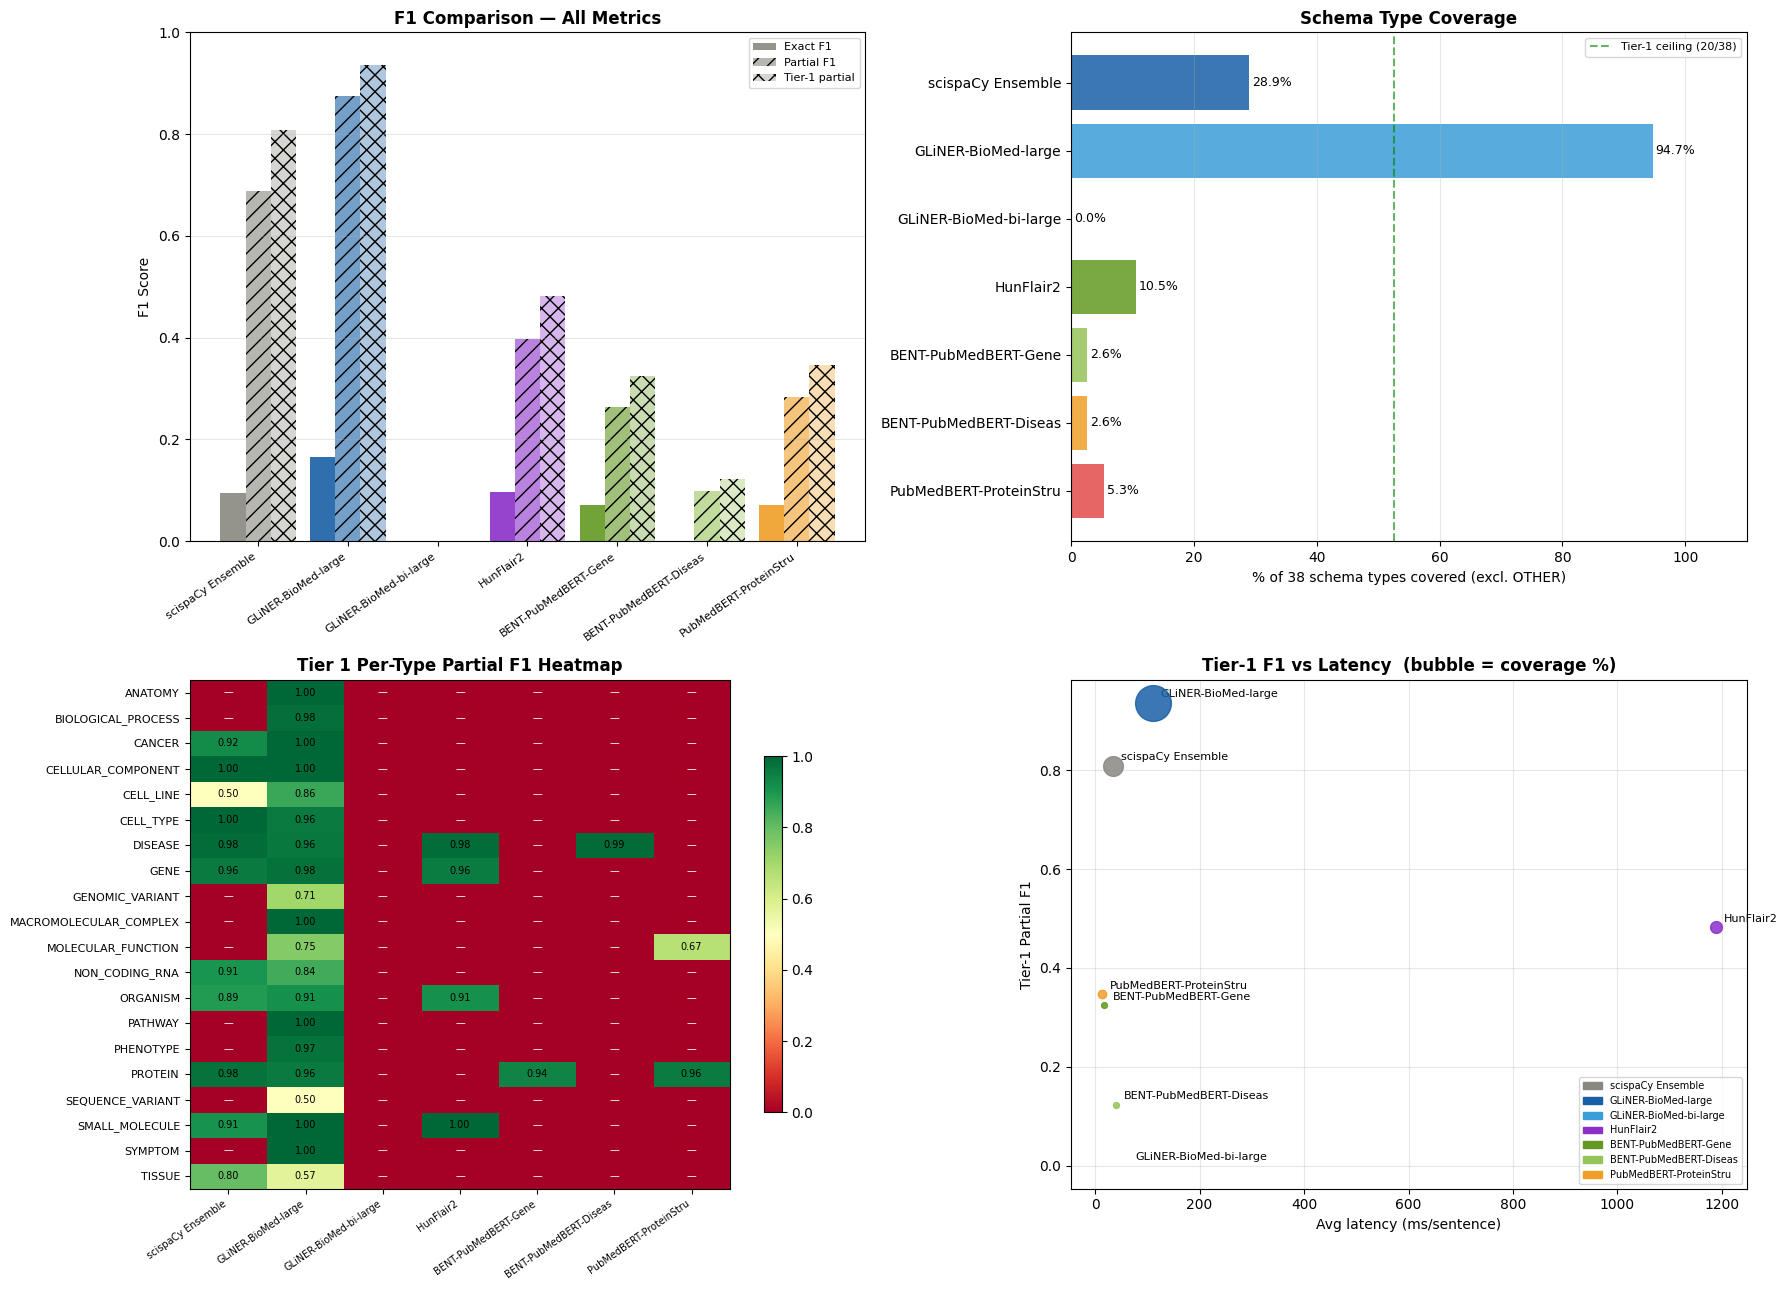

✓ Saved: ner_full_comparison.png


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

COLORS = ["#888780","#185FA5","#3B9ED8","#8B2FC9","#639922","#97C459","#EF9F27","#E24B4A"]
SHORT_NAMES = [r["model"].replace("(baseline)","").replace("-NER","").strip()[:22]
               for r in ALL_RESULTS]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# Plot 1: Overall F1 comparison
ax = axes[0,0]
x  = np.arange(len(ALL_RESULTS))
w  = 0.28
ax.bar(x-w, [r["overall"]["exact_f1"] for r in ALL_RESULTS],   w, label="Exact F1",      color=COLORS, alpha=0.9)
ax.bar(x,   [r["overall"]["partial_f1"] for r in ALL_RESULTS],  w, label="Partial F1",    color=COLORS, alpha=0.6, hatch="//")
ax.bar(x+w, [r["tier1_only"]["partial_f1"] for r in ALL_RESULTS], w, label="Tier-1 partial", color=COLORS, alpha=0.35, hatch="xx")
ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("F1 Score"); ax.set_ylim(0,1); ax.legend(fontsize=8)
ax.set_title("F1 Comparison — All Metrics", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# Plot 2: Schema coverage
ax = axes[0,1]
coverages = [r["type_coverage_pct"] for r in ALL_RESULTS]
bars = ax.barh(SHORT_NAMES[::-1], coverages[::-1], color=COLORS[::-1], alpha=0.85)
ax.set_xlabel("% of 38 schema types covered (excl. OTHER)")
ax.set_title("Schema Type Coverage", fontweight="bold")
ax.set_xlim(0, 110)
ax.axvline(100*len(TIER_1_NLP_DETECTABLE)/38, color="green", linestyle="--",
           alpha=0.6, label=f"Tier-1 ceiling ({len(TIER_1_NLP_DETECTABLE)}/38)")
ax.legend(fontsize=8)
for bar, val in zip(bars, coverages[::-1]):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f"{val}%", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)

# Plot 3: Tier 1 per-type heatmap
ax = axes[1,0]
tier1_sorted = sorted(TIER_1_NLP_DETECTABLE)
heat_data = np.array([
    [r["per_type"].get(t,{}).get("partial_f1",0.0) for r in ALL_RESULTS]
    for t in tier1_sorted
])
im = ax.imshow(heat_data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_RESULTS))); ax.set_xticklabels(SHORT_NAMES, rotation=35, ha="right", fontsize=7)
ax.set_yticks(range(len(tier1_sorted))); ax.set_yticklabels(tier1_sorted, fontsize=8)
ax.set_title("Tier 1 Per-Type Partial F1 Heatmap", fontweight="bold")
for i in range(len(tier1_sorted)):
    for j in range(len(ALL_RESULTS)):
        v = heat_data[i,j]
        ax.text(j, i, f"{v:.2f}" if v>0 else "—", ha="center", va="center",
                fontsize=7, color="white" if v<0.3 else "black")
plt.colorbar(im, ax=ax, shrink=0.7)

# Plot 4: Latency vs Tier-1 F1 scatter
ax = axes[1,1]
for i, r in enumerate(ALL_RESULTS):
    ax.scatter(r["avg_latency_ms"], r["tier1_only"]["partial_f1"],
               s=r["type_coverage_pct"]*7, color=COLORS[i], alpha=0.85, zorder=5)
    ax.annotate(SHORT_NAMES[i], (r["avg_latency_ms"], r["tier1_only"]["partial_f1"]),
                textcoords="offset points", xytext=(6,4), fontsize=8)
ax.set_xlabel("Avg latency (ms/sentence)")
ax.set_ylabel("Tier-1 Partial F1")
ax.set_title("Tier-1 F1 vs Latency  (bubble = coverage %)", fontweight="bold")
ax.grid(True, alpha=0.3)
handles = [mpatches.Patch(color=COLORS[i], label=SHORT_NAMES[i]) for i in range(len(ALL_RESULTS))]
ax.legend(handles=handles, fontsize=7, loc="lower right")

plt.tight_layout()
plt.savefig("ner_full_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ner_full_comparison.png")


In [37]:
print("=" * 80)
print("WEIGHTED SCORING")
print("Weights: Tier-1 partial F1 (40%) | schema coverage (30%) | speed (20%) | GPU mem (10%)")
print("=" * 80)

max_lat = max(r["avg_latency_ms"] for r in ALL_RESULTS)
max_mem = max(r["gpu_peak_mb"] for r in ALL_RESULTS) or 1

scored = []
for r in ALL_RESULTS:
    score = (
        r["tier1_only"]["partial_f1"]   * 0.40 +
        (r["type_coverage_pct"] / 100)  * 0.30 +
        (1 - r["avg_latency_ms"]/max_lat) * 0.20 +
        (1 - r["gpu_peak_mb"]/max_mem)    * 0.10
    )
    scored.append({**r, "score": round(score,4)})

scored.sort(key=lambda x: x["score"], reverse=True)
for i, s in enumerate(scored, 1):
    print(f"  #{i}  {s['model']}")
    print(f"       Score: {s['score']:.4f}  T1-F1: {s['tier1_only']['partial_f1']}  "
          f"Coverage: {s['type_coverage_pct']}%  {s['avg_latency_ms']}ms  {s['gpu_peak_mb']}MB")

print()
print("-" * 80)
print("RECOMMENDED 3-LAYER ARCHITECTURE")
print("-" * 80)

primary = scored[0]["model"]
print(f"""
LAYER A  - Primary (every chunk)
  Model  : {primary}
  Covers : All Tier-1 types + most Tier-2 types via natural language labels
  Fires  : Always

LAYER B  - Specialists (targeted re-verification)
  Gene / Protein   -> BENT-PubMedBERT-NER-Gene
                     Fires when: GLiNER confidence < 0.65 OR entity is GENE/PROTEIN
  Disease / Cancer -> HunFlair2  (cross-corpus SOTA for disease+chemical)
                     OR BENT-PubMedBERT-NER-Disease
                     Fires when: GLiNER confidence < 0.65 for DISEASE/CANCER
  Small molecule   -> HunFlair2  (best chemical precision in cross-corpus benchmark)
                     Fires when: GLiNER confidence < 0.65 for SMALL_MOLECULE
  Protein residue  -> PubMedBERT-ProteinStructure
                     Fires when: SEQUENCE_VARIANT in predicted span

LAYER C  - PubTator3 overlay (already implemented)
  Maps confirmed spans -> NCBI Gene IDs + MeSH IDs
  Fires  : Always, on all confirmed spans from Layers A+B

CONFLICT RESOLUTION PRIORITY (when spans overlap):
  1. PubTator3 confirmed (has canonical ID)
  2. Layer B specialist output
  3. Layer A GLiNER confidence > 0.80
  4. Layer A GLiNER confidence 0.50-0.80
  5. Drop (confidence < 0.50, no specialist confirmation)
  Tie-break: longer span wins  (mTOR complex 1  >  mTOR)

TIER-3 TYPES (TAD, MOTIF, THREE_D_GENOME_STRUCTURE, etc.):
  No NER model reliably detects these from prose alone.
  Strategy: database lookup via PubTator3/UCSC/ENCODE APIs in post-extraction layer.
  Do NOT expect NER to cover these - they are almost never mentioned by name in abstracts.
""")


WEIGHTED SCORING
Weights: Tier-1 partial F1 (40%) | schema coverage (30%) | speed (20%) | GPU mem (10%)
  #1  GLiNER-BioMed-large
       Score: 0.8776  T1-F1: 0.936  Coverage: 94.7%  109.8ms  3715.4MB
  #2  scispaCy Ensemble (baseline)
       Score: 0.6751  T1-F1: 0.809  Coverage: 28.9%  34.3ms  1754.0MB
  #3  PubMedBERT-ProteinStructure
       Score: 0.4231  T1-F1: 0.347  Coverage: 5.3%  12.7ms  1755.0MB
  #4  BENT-PubMedBERT-Gene
       Score: 0.4196  T1-F1: 0.324  Coverage: 2.6%  17.6ms  881.5MB
  #5  BENT-PubMedBERT-Disease
       Score: 0.3282  T1-F1: 0.123  Coverage: 2.6%  39.5ms  1318.2MB
  #6  HunFlair2
       Score: 0.3094  T1-F1: 0.482  Coverage: 10.5%  1188.6ms  884.5MB
  #7  GLiNER-BioMed-bi-large
       Score: 0.1896  T1-F1: 0  Coverage: 0.0%  61.7ms  5956.0MB

--------------------------------------------------------------------------------
RECOMMENDED 3-LAYER ARCHITECTURE
--------------------------------------------------------------------------------

LAYER A  - Primary 

In [38]:
from datetime import datetime

def serialize(obj):
    if isinstance(obj, dict): return {k: serialize(v) for k,v in obj.items()}
    if isinstance(obj, list): return [serialize(v) for v in obj]
    if isinstance(obj, (int,float,str,bool)) or obj is None: return obj
    return str(obj)

report = {
    "generated_at": datetime.now().isoformat(),
    "schema_version": "39 entity types (BioCypher)",
    "corpus_size": len(CORPUS),
    "total_gold_entities": sum(len(e) for _,e in CORPUS),
    "tier_breakdown": {
        "tier1_detectable": sorted(TIER_1_NLP_DETECTABLE),
        "tier2_moderate": sorted(TIER_2_NLP_MODERATE),
        "tier3_hard": sorted(TIER_3_NLP_HARD),
    },
    "models_evaluated": [r["model"] for r in ALL_RESULTS],
    "results": [serialize({
        "model":              r["model"],
        "overall":            r["overall"],
        "tier1_only":         r["tier1_only"],
        "type_coverage_pct":  r["type_coverage_pct"],
        "types_predicted":    r["types_predicted"],
        "avg_latency_ms":     r["avg_latency_ms"],
        "p95_latency_ms":     r["p95_latency_ms"],
        "gpu_peak_mb":        r["gpu_peak_mb"],
        "per_type_partial_f1":{t:v.get("partial_f1",0) for t,v in r["per_type"].items()},
        "errors":             r["errors"],
    }) for r in ALL_RESULTS],
    "ranking": serialize(scored),
    "recommended_primary": scored[0]["model"],
    "recommended_architecture": "GLiNER-BioMed-large (primary) -> PubMedBERT specialists + HunFlair2 (layer B) -> PubTator3 (layer C)",
}

with open("ner_evaluation_report_39types.json","w") as f:
    json.dump(report, f, indent=2)

md = [
    "# NER Model Evaluation Report — 39 Entity Types",
    f"Generated: {datetime.now().strftime('%Y-%m-%d')}",
    f"Corpus: {len(CORPUS)} sentences | Schema: 39 BioCypher entity types",
    "",
    "## Tier Classification",
    f"- **Tier 1 (NER-detectable):** {len(TIER_1_NLP_DETECTABLE)} types — {', '.join(sorted(TIER_1_NLP_DETECTABLE))}",
    f"- **Tier 2 (moderate):** {len(TIER_2_NLP_MODERATE)} types — {', '.join(sorted(TIER_2_NLP_MODERATE))}",
    f"- **Tier 3 (hard/structural):** {len(TIER_3_NLP_HARD)} types — {', '.join(sorted(TIER_3_NLP_HARD))}",
    "",
    "## Results",
    "",
    "| Rank | Model | Partial F1 | Tier-1 F1 | Coverage | ms |",
    "|---|---|---|---|---|---|",
]
for i,s in enumerate(scored,1):
    md.append(f"| {i} | {s['model']} | {s['overall']['partial_f1']} | "
              f"{s['tier1_only']['partial_f1']} | {s['type_coverage_pct']}% | {s['avg_latency_ms']} |")
md += ["","## Architecture","**Layer A:** GLiNER-BioMed-large",
       "**Layer B:** BENT-PubMedBERT-Gene + HunFlair2 + PubMedBERT-ProteinStructure",
       "**Layer C:** PubTator3 overlay (canonical IDs)"]

with open("ner_evaluation_report_39types.md","w") as f:
    f.write("\n".join(md))

print("✓ ner_evaluation_report_39types.json")
print("✓ ner_evaluation_report_39types.md")
print("✓ ner_full_comparison.png")


✓ ner_evaluation_report_39types.json
✓ ner_evaluation_report_39types.md
✓ ner_full_comparison.png
